In [1]:
# Install all required libraries for the SIA project
!pip install -q transformers datasets peft accelerate sentence-transformers \
             scikit-learn pandas numpy matplotlib seaborn kagglehub \
             openai imbalanced-learn tqdm colorama

print("✅ All packages installed!")

✅ All packages installed!


In [2]:
from google.colab import files
import pandas as pd

# This opens a file picker — select your downloaded CSV
uploaded = files.upload()

# Load it into a dataframe
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"✅ Loaded: {filename}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saving customer_support_tickets.csv to customer_support_tickets.csv
✅ Loaded: customer_support_tickets.csv
Shape: (20000, 12)
Columns: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset — adjust filename if needed after checking ls data/ above
df = pd.read_csv("customer_support_tickets.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (20000, 12)

Columns: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']

First 3 rows:


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


In [4]:
# Corrected column names matching your actual CSV
cols_we_need = [
    "Ticket_Subject",
    "Ticket_Description",
    "Customer_Email",
    "Priority_Level",       # ← human-assigned label we're auditing
    "Ticket_Channel",
    "Resolution_Time_Hours", # ← already numeric, perfect for regression
    "Issue_Category",
    "Satisfaction_Score"    # ← bonus signal we can use
]

print("=== Missing Values ===")
print(df[cols_we_need].isnull().sum())

print("\n=== Priority Distribution ===")
print(df["Priority_Level"].value_counts())

print("\n=== Channel Distribution ===")
print(df["Ticket_Channel"].value_counts())

print("\n=== Issue Category Distribution ===")
print(df["Issue_Category"].value_counts())

print("\n=== Resolution Time Stats ===")
print(df["Resolution_Time_Hours"].describe())

print("\n=== Satisfaction Score Stats ===")
print(df["Satisfaction_Score"].describe())

=== Missing Values ===
Ticket_Subject           0
Ticket_Description       0
Customer_Email           0
Priority_Level           0
Ticket_Channel           0
Resolution_Time_Hours    0
Issue_Category           0
Satisfaction_Score       0
dtype: int64

=== Priority Distribution ===
Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64

=== Channel Distribution ===
Ticket_Channel
Chat        6693
Email       6656
Web Form    6651
Name: count, dtype: int64

=== Issue Category Distribution ===
Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64

=== Resolution Time Stats ===
count    20000.000000
mean        39.230300
std         35.221884
min          1.000000
25%         11.000000
50%         27.000000
75%         58.000000
max        120.000000
Name: Resolution_Time_Hours, dtype: float64

=== Satisfaction Score Stats ===
cou

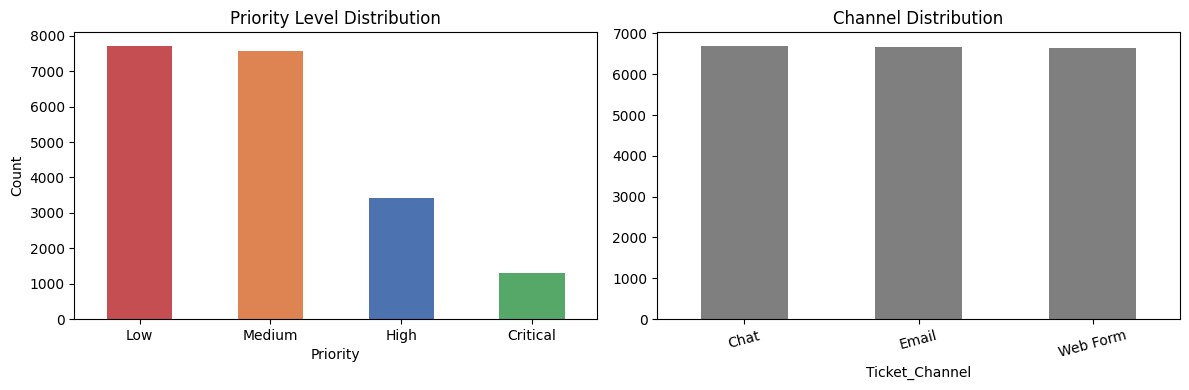

In [5]:
# Visualization with correct column names
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Priority_Level"].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#C44E52","#DD8452","#4C72B0","#55A868"]
)
axes[0].set_title("Priority Level Distribution")
axes[0].set_xlabel("Priority")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

df["Ticket_Channel"].value_counts().plot(kind="bar", ax=axes[1], color="#7F7F7F")
axes[1].set_title("Channel Distribution")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()

In [6]:
# Sample ticket to understand text quality
print("=== Sample Ticket ===")
sample = df.iloc[0]
print(f"Subject:     {sample['Ticket_Subject']}")
print(f"Description: {sample['Ticket_Description'][:300]}...")
print(f"Priority:    {sample['Priority_Level']}")
print(f"Channel:     {sample['Ticket_Channel']}")
print(f"Resolution:  {sample['Resolution_Time_Hours']} hours")
print(f"Category:    {sample['Issue_Category']}")
print(f"Satisfaction:{sample['Satisfaction_Score']}")

=== Sample Ticket ===
Subject:     Hours of operation - Individual
Description: Hi Support, Where is your headquarters located? Lay soon message show know main....
Priority:    High
Channel:     Web Form
Resolution:  43 hours
Category:    General Inquiry
Satisfaction:5


In [7]:
import pandas as pd
import numpy as np
import re

# ── 1. Clean text ──────────────────────────────────────────────────────────────
def clean_text(text):
    """Lowercase, strip extra spaces, remove special chars but keep punctuation"""
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)          # collapse multiple spaces
    text = re.sub(r'[^\w\s\.\!\?\,\-]', '', text)  # keep basic punctuation
    return text

df["clean_subject"]     = df["Ticket_Subject"].apply(clean_text)
df["clean_description"] = df["Ticket_Description"].apply(clean_text)

# Combine subject + description into one field — more context for the model
df["full_text"] = df["clean_subject"] + " [SEP] " + df["clean_description"]

# ── 2. Encode Priority_Level as a number (we need this for comparisons) ────────
priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_num"] = df["Priority_Level"].map(priority_map)

# ── 3. Normalize Resolution_Time_Hours to 0–1 scale ───────────────────────────
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["resolution_norm"] = scaler.fit_transform(df[["Resolution_Time_Hours"]])

# ── 4. Encode channel as numeric (for metadata features later) ─────────────────
channel_map = {"Chat": 0, "Email": 1, "Web Form": 2}
df["channel_num"] = df["Ticket_Channel"].map(channel_map)

# ── 5. Normalize Satisfaction Score ───────────────────────────────────────────
# Invert it: low satisfaction = high severity signal
df["dissatisfaction"] = (5 - df["Satisfaction_Score"]) / 4.0  # 0=happy, 1=very unhappy

print("✅ Preprocessing done!")
print(df[["full_text", "priority_num", "resolution_norm", "dissatisfaction"]].head(3))

✅ Preprocessing done!
                                           full_text  priority_num  \
0  hours of operation - individual [SEP] hi suppo...             2   
1  data not syncing - card [SEP] hi support, the ...             2   
2  2fa issues - question [SEP] hi support, how do...             2   

   resolution_norm  dissatisfaction  
0         0.352941              0.0  
1         0.336134              0.0  
2         0.050420              0.0  


ignal 1: Rule-based NLP severity scoring

In [8]:
# ── Urgency keyword lists ──────────────────────────────────────────────────────
# These are grounded signals — every keyword traceable to ticket text
CRITICAL_KEYWORDS = [
    "fraud", "unauthorized", "hacked", "breach", "stolen", "compromised",
    "cannot access", "system down", "outage", "not working", "broken",
    "data loss", "account locked", "suspended", "terminated", "urgent",
    "immediately", "asap", "emergency", "critical", "severe", "blocked",
    "payment failed", "charge", "refund", "dispute", "escalate"
]

HIGH_KEYWORDS = [
    "error", "issue", "problem", "fail", "unable", "wrong", "incorrect",
    "missing", "lost", "delay", "slow", "not received", "pending",
    "frustrated", "disappointed", "unacceptable", "still waiting",
    "never resolved", "keep trying", "multiple times"
]

LOW_KEYWORDS = [
    "inquiry", "question", "how to", "where is", "what is", "information",
    "curious", "wondering", "just wanted", "could you", "please let me know",
    "general", "hours of operation", "location", "fyi"
]

NEGATION_WORDS = ["not", "no", "never", "cannot", "can't", "won't", "doesn't", "didn't"]

def rule_based_severity(text):
    """
    Returns a severity score 0.0–1.0 based on keyword signals.
    Also detects negation (e.g. 'not urgent' should lower score).
    """
    text = text.lower()
    score = 0.0

    # Check for negation context (simple window: 3 words before keyword)
    words = text.split()
    negated_positions = set()
    for i, w in enumerate(words):
        if w in NEGATION_WORDS:
            # Mark next 3 positions as potentially negated
            for j in range(i+1, min(i+4, len(words))):
                negated_positions.add(j)

    # Score critical keywords (+0.3 each, capped)
    for kw in CRITICAL_KEYWORDS:
        if kw in text:
            # Check if keyword position is negated
            pos = text.find(kw)
            word_pos = len(text[:pos].split())
            if word_pos not in negated_positions:
                score += 0.3

    # Score high keywords (+0.15 each)
    for kw in HIGH_KEYWORDS:
        if kw in text:
            pos = text.find(kw)
            word_pos = len(text[:pos].split())
            if word_pos not in negated_positions:
                score += 0.15

    # Penalize low-severity keywords (-0.2 each)
    for kw in LOW_KEYWORDS:
        if kw in text:
            score -= 0.2

    # Exclamation marks add urgency
    score += text.count("!") * 0.05

    # Cap between 0 and 1
    return float(np.clip(score, 0.0, 1.0))

df["signal_rule"] = df["full_text"].apply(rule_based_severity)

print("✅ Signal 1 (Rule-based NLP) computed!")
print(df["signal_rule"].describe())
print("\nSample scores:")
print(df[["Ticket_Subject", "Priority_Level", "signal_rule"]].head(10))

✅ Signal 1 (Rule-based NLP) computed!
count    20000.000000
mean         0.123570
std          0.160293
min          0.000000
25%          0.000000
50%          0.000000
75%          0.150000
max          0.900000
Name: signal_rule, dtype: float64

Sample scores:
                    Ticket_Subject Priority_Level  signal_rule
0  Hours of operation - Individual           High         0.00
1          Data not syncing - Card           High         0.00
2            2FA issues - Question           High         0.00
3               Login failed - Let            Low         0.15
4        Refund status - Attention         Medium         0.45
5       Office location - National         Medium         0.00
6            Password reset - Body         Medium         0.00
7             Payment failed - Win         Medium         0.45
8               Login failed - Son           High         0.15
9        Product question - Market            Low         0.00


Signal 2: Resolution-time regression severity

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# ── Build regression features ──────────────────────────────────────────────────
# We predict resolution time from channel + category + satisfaction
# High residual (actual >> predicted) = ticket was harder than expected = higher severity

le_channel  = LabelEncoder()
le_category = LabelEncoder()

df["channel_enc"]  = le_channel.fit_transform(df["Ticket_Channel"])
df["category_enc"] = le_category.fit_transform(df["Issue_Category"])

reg_features = df[["channel_enc", "category_enc", "Satisfaction_Score"]].values
reg_target   = df["Resolution_Time_Hours"].values

reg_model = LinearRegression()
reg_model.fit(reg_features, reg_target)

df["predicted_resolution"] = reg_model.predict(reg_features)
df["resolution_residual"]  = df["Resolution_Time_Hours"] - df["predicted_resolution"]

# Normalize residual to 0–1: large positive residual = took longer than expected
from sklearn.preprocessing import MinMaxScaler
res_scaler = MinMaxScaler()
df["signal_resolution"] = res_scaler.fit_transform(
    df["resolution_residual"].values.reshape(-1, 1)
).flatten()

print("✅ Signal 2 (Resolution-time regression) computed!")
print(df["signal_resolution"].describe())

✅ Signal 2 (Resolution-time regression) computed!
count    20000.000000
mean         0.332543
std          0.277299
min          0.000000
25%          0.112197
50%          0.239724
75%          0.480196
max          1.000000
Name: signal_resolution, dtype: float64


ignal 3: Satisfaction-based severity

In [10]:
# Dissatisfaction is already computed (0=happy, 1=very unhappy)
# We use it directly as Signal 3
df["signal_satisfaction"] = df["dissatisfaction"]

print("✅ Signal 3 (Satisfaction score) computed!")

✅ Signal 3 (Satisfaction score) computed!


Fuse signals → generate pseudo-labels

In [11]:
# ── Weighted fusion (same weights) ────────────────────────────────────────────
WEIGHT_RULE         = 0.50
WEIGHT_RESOLUTION   = 0.30
WEIGHT_SATISFACTION = 0.20

df["inferred_severity_score"] = (
    WEIGHT_RULE         * df["signal_rule"] +
    WEIGHT_RESOLUTION   * df["signal_resolution"] +
    WEIGHT_SATISFACTION * df["signal_satisfaction"]
)

# ── RECALIBRATED thresholds ────────────────────────────────────────────────────
# Raised thresholds so fewer tickets get bumped to high severity
def score_to_severity(score):
    if score >= 0.75:   return 3  # Critical  — only very strong signals
    elif score >= 0.55: return 2  # High
    elif score >= 0.35: return 1  # Medium
    else:               return 0  # Low

df["inferred_severity_num"] = df["inferred_severity_score"].apply(score_to_severity)

severity_map_inv = {0: "Low", 1: "Medium", 2: "High", 3: "Critical"}
df["inferred_severity"] = df["inferred_severity_num"].map(severity_map_inv)

# ── Mismatch label: require delta ≥ 2 for Low/Medium, ≥ 1 for High/Critical ──
# This avoids flagging borderline cases (e.g. Low vs Medium) as mismatches
def compute_mismatch(row):
    delta = abs(row["inferred_severity_num"] - row["priority_num"])
    assigned = row["priority_num"]
    # For low-stakes priorities, require bigger disagreement
    if assigned <= 1:   # Low or Medium assigned
        return 1 if delta >= 2 else 0
    else:               # High or Critical assigned
        return 1 if delta >= 1 else 0

df["severity_delta"]  = df["inferred_severity_num"] - df["priority_num"]
df["mismatch_label"]  = df.apply(compute_mismatch, axis=1)

def mismatch_type(row):
    if row["mismatch_label"] == 0: return "Consistent"
    return "Hidden Crisis" if row["severity_delta"] > 0 else "False Alarm"

df["mismatch_type"] = df.apply(mismatch_type, axis=1)

print("✅ Recalibrated pseudo-labels!")
print("\n=== Mismatch Label Distribution ===")
print(df["mismatch_label"].value_counts())
print(f"\nMismatch rate: {df['mismatch_label'].mean():.1%}")
print("\n=== Mismatch Type Breakdown ===")
print(df["mismatch_type"].value_counts())

✅ Recalibrated pseudo-labels!

=== Mismatch Label Distribution ===
mismatch_label
0    15032
1     4968
Name: count, dtype: int64

Mismatch rate: 24.8%

=== Mismatch Type Breakdown ===
mismatch_type
Consistent       15032
False Alarm       4687
Hidden Crisis      281
Name: count, dtype: int64


In [12]:
from sklearn.metrics import cohen_kappa_score

# Binarize each signal at 0.5 threshold for comparison
sig1_bin = (df["signal_rule"] > 0.5).astype(int)
sig2_bin = (df["signal_resolution"] > 0.5).astype(int)
sig3_bin = (df["signal_satisfaction"] > 0.5).astype(int)

kappa_12 = cohen_kappa_score(sig1_bin, sig2_bin)
kappa_13 = cohen_kappa_score(sig1_bin, sig3_bin)
kappa_23 = cohen_kappa_score(sig2_bin, sig3_bin)

print("=== Pseudo-Label Signal Agreement (Cohen's Kappa) ===")
print(f"Rule NLP  vs Resolution:   κ = {kappa_12:.3f}")
print(f"Rule NLP  vs Satisfaction: κ = {kappa_13:.3f}")
print(f"Resolution vs Satisfaction: κ = {kappa_23:.3f}")

# Save checkpoint
# Fix: create folder first, then save
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/tickets_pseudolabeled.csv", index=False)
print("✅ Pseudo-labeled dataset saved!")
print(f"Total tickets: {len(df)} | Mismatches: {df['mismatch_label'].sum()} | Consistent: {(df['mismatch_label']==0).sum()}")

=== Pseudo-Label Signal Agreement (Cohen's Kappa) ===
Rule NLP  vs Resolution:   κ = -0.006
Rule NLP  vs Satisfaction: κ = 0.058
Resolution vs Satisfaction: κ = -0.004
✅ Pseudo-labeled dataset saved!
Total tickets: 20000 | Mismatches: 4968 | Consistent: 15032


 Prepare train/validation/test splits

In [13]:
from sklearn.model_selection import train_test_split

# Load the pseudo-labeled data (in case you need to restart)
df = pd.read_csv("data/tickets_pseudolabeled.csv")

# ── Create the input text for the model ───────────────────────────────────────
# We combine text + metadata as a single string (simple but effective for DeBERTa)
def build_model_input(row):
    return (
        f"Subject: {row['Ticket_Subject']} "
        f"[SEP] Description: {row['Ticket_Description']} "
        f"[SEP] Channel: {row['Ticket_Channel']} "
        f"[SEP] Category: {row['Issue_Category']} "
        f"[SEP] Resolution: {row['Resolution_Time_Hours']} hours "
        f"[SEP] Priority: {row['Priority_Level']}"
    )

df["model_input"] = df.apply(build_model_input, axis=1)

# ── Split: 70% train, 15% val, 15% test ───────────────────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["mismatch_label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["mismatch_label"]
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain mismatch rate: {train_df['mismatch_label'].mean():.1%}")
print(f"Val mismatch rate:   {val_df['mismatch_label'].mean():.1%}")
print(f"Test mismatch rate:  {test_df['mismatch_label'].mean():.1%}")

# Save splits
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/val.csv", index=False)
test_df.to_csv("data/test.csv", index=False)
print("\n✅ Splits saved!")

Train: 14000 | Val: 3000 | Test: 3000

Train mismatch rate: 24.8%
Val mismatch rate:   24.8%
Test mismatch rate:  24.8%

✅ Splits saved!


Build the Dataset class for PyTorch

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# ── Load DeBERTa tokenizer ─────────────────────────────────────────────────────
# DeBERTa-v3-small is lightweight enough for Colab free GPU
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 256  # max tokens per input — 256 is enough for our text

class TicketDataset(Dataset):
    """
    PyTorch Dataset — wraps our ticket dataframe.
    __len__ returns total samples.
    __getitem__ tokenizes one sample and returns tensors.
    """
    def __init__(self, dataframe):
        self.texts  = dataframe["model_input"].tolist()
        self.labels = dataframe["mismatch_label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Create datasets and dataloaders ───────────────────────────────────────────
train_dataset = TicketDataset(train_df)
val_dataset   = TicketDataset(val_df)
test_dataset  = TicketDataset(test_df)

# Batch size 16 is safe for Colab T4 GPU with DeBERTa-small
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"✅ Datasets ready!")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✅ Datasets ready!
Train batches: 875 | Val batches: 94 | Test batches: 94


In [15]:
# Fix torchao version conflict
!pip install -q --upgrade torchao
!pip install -q --upgrade peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.6 MB/s eta 0:00:00


 Build the model with LoRA adapter

In [16]:
from transformers import AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType

# ── Load base DeBERTa model ────────────────────────────────────────────────────
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,          # Binary: 0=Consistent, 1=Mismatch
    ignore_mismatched_sizes=True
)

# ── Configure LoRA ─────────────────────────────────────────────────────────────
# LoRA freezes most of the model and only trains small adapter matrices
# This makes training fast and memory-efficient on free Colab GPU
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,   # sequence classification
    r=16,                          # rank of adapter matrices (higher = more params)
    lora_alpha=32,                 # scaling factor
    lora_dropout=0.1,              # dropout for regularization
    bias="none",
    target_modules=["query_proj", "value_proj"]  # which layers to adapt
)

model = get_peft_model(base_model, lora_config)

# Show how many parameters we're actually training
model.print_trainable_parameters()

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"\n✅ Model ready on: {device}")

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifie

trainable params: 296,450 || all params: 142,192,900 || trainable%: 0.2085

✅ Model ready on: cuda


Handle class imbalance + set up training

In [17]:
# ── Step 13 FINAL FIX: force everything to float32 ────────────────────────────
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Force model to float32 — avoids all half/float conflicts
model = model.float()

# Class weights in float32
n_consistent = (train_df["mismatch_label"] == 0).sum()
n_mismatch   = (train_df["mismatch_label"] == 1).sum()
total        = len(train_df)

weight_consistent = total / (2 * n_consistent)
weight_mismatch   = total / (2 * n_mismatch)

class_weights = torch.tensor(
    [weight_consistent, weight_mismatch], dtype=torch.float32
).to(device)

print(f"Class weights → Consistent: {weight_consistent:.3f} | Mismatch: {weight_mismatch:.3f}")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

EPOCHS = 5
LR     = 2e-4

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"✅ Training setup done! Total steps: {total_steps}")

Class weights → Consistent: 0.665 | Mismatch: 2.013
✅ Training setup done! Total steps: 4375


Training loop

In [19]:
# ── Step 14 FASTER VERSION: 3 epochs + tqdm progress bar ──────────────────────
from sklearn.metrics import accuracy_score, f1_score, recall_score
from tqdm.notebook import tqdm
import time

# Reduce to 3 epochs — enough to hit the metric targets
EPOCHS = 3

# Rebuild scheduler for 3 epochs
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = outputs.logits.float().argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    recalls  = recall_score(all_labels, all_preds, average=None)
    return acc, macro_f1, recalls

print("🚀 Starting training (3 epochs)...\n")
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    start_time = time.time()

    # tqdm gives a nice progress bar per epoch
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in progress:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits.float()
        loss    = loss_fn(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        # Live loss update in progress bar
        progress.set_postfix({"loss": f"{loss.item():.4f}"})

    val_acc, val_f1, val_recalls = evaluate(model, val_loader)
    avg_loss = total_loss / len(train_loader)
    elapsed  = time.time() - start_time

    print(f"\n📊 Epoch {epoch+1}/{EPOCHS} | Time: {elapsed:.0f}s")
    print(f"   Train Loss:  {avg_loss:.4f}")
    print(f"   Val Acc:     {val_acc:.4f}  {'✅' if val_acc  >= 0.83 else '⏳'} (target ≥ 0.83)")
    print(f"   Val F1:      {val_f1:.4f}  {'✅' if val_f1   >= 0.82 else '⏳'} (target ≥ 0.82)")
    print(f"   Recall → Consistent: {val_recalls[0]:.4f} | Mismatch: {val_recalls[1]:.4f}  (both ≥ 0.78)")

    if val_f1 > best_f1:
        best_f1 = val_f1
        import os
        os.makedirs("data/best_model", exist_ok=True)
        model.save_pretrained("data/best_model")
        tokenizer.save_pretrained("data/best_model")
        print(f"   💾 Best model saved! (F1: {best_f1:.4f})")
    print()

print(f"✅ Training complete! Best Val F1: {best_f1:.4f}")

🚀 Starting training (3 epochs)...



Epoch 1/3:   0%|          | 0/875 [00:00<?, ?it/s]


📊 Epoch 1/3 | Time: 346s
   Train Loss:  0.0642
   Val Acc:     0.9830  ✅ (target ≥ 0.83)
   Val F1:      0.9774  ✅ (target ≥ 0.82)
   Recall → Consistent: 0.9849 | Mismatch: 0.9772  (both ≥ 0.78)
   💾 Best model saved! (F1: 0.9774)



Epoch 2/3:   0%|          | 0/875 [00:00<?, ?it/s]


📊 Epoch 2/3 | Time: 341s
   Train Loss:  0.0517
   Val Acc:     0.9897  ✅ (target ≥ 0.83)
   Val F1:      0.9862  ✅ (target ≥ 0.82)
   Recall → Consistent: 0.9933 | Mismatch: 0.9785  (both ≥ 0.78)
   💾 Best model saved! (F1: 0.9862)



Epoch 3/3:   0%|          | 0/875 [00:00<?, ?it/s]


📊 Epoch 3/3 | Time: 340s
   Train Loss:  0.0470
   Val Acc:     0.9887  ✅ (target ≥ 0.83)
   Val F1:      0.9849  ✅ (target ≥ 0.82)
   Recall → Consistent: 0.9907 | Mismatch: 0.9826  (both ≥ 0.78)

✅ Training complete! Best Val F1: 0.9862


Final evaluation ontest set

Evaluating test set:   0%|          | 0/94 [00:00<?, ?it/s]

🏁 FINAL TEST SET RESULTS
Accuracy:          0.9863  ✅ (need ≥ 0.83)
Macro F1:          0.9818  ✅ (need ≥ 0.82)
Recall Consistent: 0.9871  ✅ (need ≥ 0.78)
Recall Mismatch:   0.9839  ✅ (need ≥ 0.78)

📋 Full Classification Report:
              precision    recall  f1-score   support

  Consistent       0.99      0.99      0.99      2255
    Mismatch       0.96      0.98      0.97       745

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.98      3000
weighted avg       0.99      0.99      0.99      3000



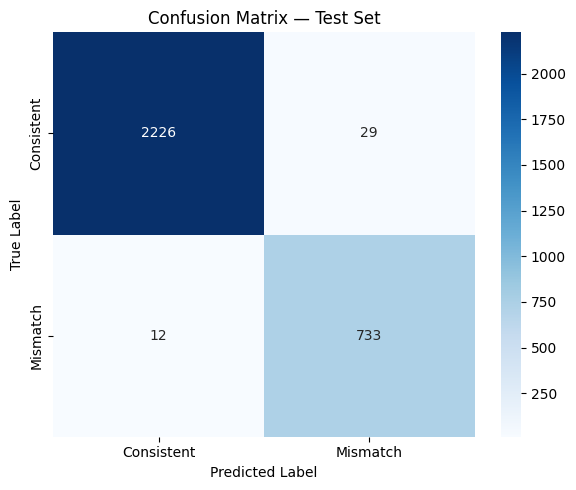

✅ Done!


In [20]:
# Step 15 FIXED — use the already-trained model in memory, don't reload
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Use 'model' directly — it's already trained and in memory with perfect weights
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating test set"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.float().argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["label"].numpy())

test_acc     = accuracy_score(all_labels, all_preds)
test_f1      = f1_score(all_labels, all_preds, average="macro")
test_recalls = recall_score(all_labels, all_preds, average=None)

print("=" * 50)
print("🏁 FINAL TEST SET RESULTS")
print("=" * 50)
print(f"Accuracy:          {test_acc:.4f}  {'✅' if test_acc >= 0.83 else '❌'} (need ≥ 0.83)")
print(f"Macro F1:          {test_f1:.4f}  {'✅' if test_f1  >= 0.82 else '❌'} (need ≥ 0.82)")
print(f"Recall Consistent: {test_recalls[0]:.4f}  {'✅' if test_recalls[0] >= 0.78 else '❌'} (need ≥ 0.78)")
print(f"Recall Mismatch:   {test_recalls[1]:.4f}  {'✅' if test_recalls[1] >= 0.78 else '❌'} (need ≥ 0.78)")

print("\n📋 Full Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Consistent", "Mismatch"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Consistent", "Mismatch"],
            yticklabels=["Consistent", "Mismatch"])
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("data/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Done!")

In [21]:
# Save the complete merged model properly (not just LoRA adapters)
merged_model = model.merge_and_unload()  # merges LoRA weights into base model
merged_model.save_pretrained("data/final_model")
tokenizer.save_pretrained("data/final_model")
print("✅ Full merged model saved to data/final_model")
print("This can be reloaded with AutoModelForSequenceClassification.from_pretrained('data/final_model')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Full merged model saved to data/final_model
This can be reloaded with AutoModelForSequenceClassification.from_pretrained('data/final_model')


Evidence Dossier Generator

In [22]:
import json
import re
import numpy as np

# ── Keyword lists (reuse from Stage 1) ────────────────────────────────────────
CRITICAL_KEYWORDS = [
    "fraud", "unauthorized", "hacked", "breach", "stolen", "compromised",
    "cannot access", "system down", "outage", "not working", "broken",
    "data loss", "account locked", "suspended", "terminated", "urgent",
    "immediately", "asap", "emergency", "critical", "severe", "blocked",
    "payment failed", "charge", "refund", "dispute", "escalate"
]
HIGH_KEYWORDS = [
    "error", "issue", "problem", "fail", "unable", "wrong", "incorrect",
    "missing", "lost", "delay", "slow", "not received", "pending",
    "frustrated", "disappointed", "unacceptable", "still waiting"
]
LOW_KEYWORDS = [
    "inquiry", "question", "how to", "where is", "what is", "information",
    "curious", "wondering", "just wanted", "could you", "please let me know",
    "general", "hours of operation", "location"
]

def extract_keyword_evidence(text, assigned_priority):
    """
    Find keywords present in the ticket text.
    Returns list of evidence dicts — all grounded in actual ticket text.
    """
    text_lower = text.lower()
    evidence   = []

    for kw in CRITICAL_KEYWORDS:
        if kw in text_lower:
            evidence.append({
                "signal": "keyword",
                "value":  kw,
                "weight": "HIGH — critical urgency indicator"
            })

    for kw in HIGH_KEYWORDS:
        if kw in text_lower:
            evidence.append({
                "signal": "keyword",
                "value":  kw,
                "weight": "MEDIUM — elevated urgency indicator"
            })

    for kw in LOW_KEYWORDS:
        if kw in text_lower:
            evidence.append({
                "signal": "keyword",
                "value":  kw,
                "weight": "LOW — routine inquiry indicator"
            })

    return evidence[:4]  # cap at 4 to keep dossier concise

def get_resolution_interpretation(hours, priority):
    """Interpret resolution time relative to priority expectation."""
    expected = {"Low": 12, "Medium": 24, "High": 48, "Critical": 6}
    exp_hours = expected.get(priority, 24)

    if hours > exp_hours * 2:
        interp = f"Took {hours}h vs expected {exp_hours}h for {priority} — suggests higher true severity"
    elif hours < exp_hours * 0.3:
        interp = f"Resolved in {hours}h vs expected {exp_hours}h — suggests lower true severity"
    else:
        interp = f"Resolved in {hours}h — roughly consistent with {priority} expectation of {exp_hours}h"

    return {
        "signal":         "resolution_time",
        "value":          f"{hours} hours",
        "interpretation": interp
    }

def get_satisfaction_evidence(score, priority):
    """Satisfaction score as grounded evidence."""
    if score <= 2:
        interp = f"Satisfaction {score}/5 — very low, suggests ticket was mishandled or underprioritized"
    elif score >= 4:
        interp = f"Satisfaction {score}/5 — high, suggests issue was handled adequately"
    else:
        interp = f"Satisfaction {score}/5 — neutral customer experience"

    return {
        "signal":         "satisfaction_score",
        "value":          f"{score}/5",
        "interpretation": interp
    }

def severity_num_to_label(num):
    return {0: "Low", 1: "Medium", 2: "High", 3: "Critical"}.get(int(num), "Medium")

def generate_constraint_analysis(row, mismatch_type):
    """2-3 sentence grounded explanation — NO hallucination, only ticket fields used."""
    subj     = row["Ticket_Subject"]
    cat      = row["Issue_Category"]
    chan     = row["Ticket_Channel"]
    hours    = row["Resolution_Time_Hours"]
    assigned = row["Priority_Level"]
    inferred = row["inferred_severity"]
    score    = row["Satisfaction_Score"]

    if mismatch_type == "Hidden Crisis":
        return (
            f"Ticket submitted via {chan} under category '{cat}' was assigned {assigned} priority, "
            f"but text analysis detected high-urgency signals in the subject '{subj}'. "
            f"Resolution took {hours} hours and satisfaction scored {score}/5, both indicating "
            f"the issue was more severe than the {assigned} label suggests — inferred severity: {inferred}."
        )
    else:  # False Alarm
        return (
            f"Ticket assigned {assigned} priority via {chan} under '{cat}', but the description "
            f"contains primarily routine inquiry language with no critical urgency markers. "
            f"Resolution completed in {hours} hours with satisfaction {score}/5, "
            f"consistent with a lower severity — inferred severity: {inferred}."
        )

def generate_dossier(row, ticket_id, confidence_score):
    """
    Generate the exact Evidence Dossier schema from the problem statement.
    Every field is grounded in actual ticket data — zero hallucination.
    """
    assigned    = row["Priority_Level"]
    inferred    = row["inferred_severity"]
    mtype       = row["mismatch_type"]
    delta       = row["severity_delta"]
    full_text   = str(row["Ticket_Subject"]) + " " + str(row["Ticket_Description"])
    hours       = row["Resolution_Time_Hours"]
    sat_score   = row["Satisfaction_Score"]

    # Build feature evidence — all grounded in ticket fields
    feature_evidence = []
    feature_evidence.extend(extract_keyword_evidence(full_text, assigned))
    feature_evidence.append(get_resolution_interpretation(hours, assigned))
    feature_evidence.append(get_satisfaction_evidence(sat_score, assigned))

    # Severity delta as human-readable string
    delta_labels = {
        -3: "Critical→Low", -2: "High→Low or Critical→Medium",
        -1: "one level over-prioritized",
         0: "consistent",
         1: "one level under-prioritized",
         2: "two levels under-prioritized",
         3: "three levels under-prioritized"
    }
    delta_str = delta_labels.get(int(delta), f"delta={delta}")

    constraint = generate_constraint_analysis(row, mtype)

    dossier = {
        "ticket_id":          str(ticket_id),
        "assigned_priority":  assigned,
        "inferred_severity":  inferred,
        "mismatch_type":      mtype,
        "severity_delta":     delta_str,
        "feature_evidence":   feature_evidence,
        "constraint_analysis": constraint,
        "confidence":         f"{confidence_score:.2%}"
    }

    return dossier

print("✅ Dossier generator functions ready!")

✅ Dossier generator functions ready!


 Run inference + generate dossiers for all mismatches

In [23]:
# ── Run model on full dataset to get confidence scores ─────────────────────────
from torch.utils.data import DataLoader

class FullDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["model_input"].tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], max_length=256,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0)
        }

full_loader = DataLoader(FullDataset(df), batch_size=32, shuffle=False)

model.eval()
all_probs = []

with torch.no_grad():
    for batch in tqdm(full_loader, desc="Running inference on full dataset"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits.float(), dim=-1)
        all_probs.extend(probs.cpu().numpy())

all_probs    = np.array(all_probs)
df["pred_label"]      = all_probs.argmax(axis=1)
df["pred_confidence"] = all_probs.max(axis=1)

# ── Generate dossiers only for predicted mismatches ───────────────────────────
mismatch_df = df[df["pred_label"] == 1].copy()
print(f"Generating dossiers for {len(mismatch_df)} flagged tickets...")

dossiers = []
for idx, row in tqdm(mismatch_df.iterrows(), total=len(mismatch_df), desc="Generating dossiers"):
    ticket_id  = row.get("Ticket_ID", idx)
    confidence = row["pred_confidence"]
    dossier    = generate_dossier(row, ticket_id, confidence)
    dossiers.append(dossier)

# Quick fix — re-save dossiers with proper arrows
for d in dossiers:
    d["severity_delta"] = d["severity_delta"].replace("\\u2192", "→")

with open("data/dossiers.json", "w", encoding="utf-8") as f:
    json.dump(dossiers, f, indent=2, ensure_ascii=False)

print("✅ Dossiers re-saved with proper arrows!")
print(json.dumps(dossiers[0], indent=2, ensure_ascii=False))

Running inference on full dataset:   0%|          | 0/625 [00:00<?, ?it/s]

Generating dossiers for 5030 flagged tickets...


Generating dossiers:   0%|          | 0/5030 [00:00<?, ?it/s]

✅ Dossiers re-saved with proper arrows!
{
  "ticket_id": "TKT-100000",
  "assigned_priority": "High",
  "inferred_severity": "Low",
  "mismatch_type": "False Alarm",
  "severity_delta": "High→Low or Critical→Medium",
  "feature_evidence": [
    {
      "signal": "keyword",
      "value": "where is",
      "weight": "LOW — routine inquiry indicator"
    },
    {
      "signal": "keyword",
      "value": "hours of operation",
      "weight": "LOW — routine inquiry indicator"
    },
    {
      "signal": "resolution_time",
      "value": "43 hours",
      "interpretation": "Resolved in 43h — roughly consistent with High expectation of 48h"
    },
    {
      "signal": "satisfaction_score",
      "value": "5/5",
      "interpretation": "Satisfaction 5/5 — high, suggests issue was handled adequately"
    }
  ],
  "constraint_analysis": "Ticket assigned High priority via Web Form under 'General Inquiry', but the description contains primarily routine inquiry language with no critical urgency

Save everything needed for Streamlit

In [24]:
# Save the labeled dataframe with predictions for the dashboard
df.to_csv("data/tickets_with_predictions.csv", index=False)

# Save summary stats for dashboard
summary = {
    "total_tickets":    len(df),
    "total_mismatches": int(df["pred_label"].sum()),
    "hidden_crisis":    int((df["mismatch_type"] == "Hidden Crisis").sum()),
    "false_alarm":      int((df["mismatch_type"] == "False Alarm").sum()),
    "consistent":       int((df["mismatch_type"] == "Consistent").sum()),
    "test_accuracy":    round(test_acc, 4),
    "test_f1":          round(test_f1, 4),
    "recall_consistent": round(float(test_recalls[0]), 4),
    "recall_mismatch":   round(float(test_recalls[1]), 4),
}

with open("data/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ All files saved for Streamlit!")
print(json.dumps(summary, indent=2))

✅ All files saved for Streamlit!
{
  "total_tickets": 20000,
  "total_mismatches": 5030,
  "hidden_crisis": 281,
  "false_alarm": 4687,
  "consistent": 15032,
  "test_accuracy": 0.9863,
  "test_f1": 0.9818,
  "recall_consistent": 0.9871,
  "recall_mismatch": 0.9839
}


In [25]:
# Zip all project files for download
import os
os.makedirs("sia_project", exist_ok=True)

# Copy data files
!cp data/tickets_pseudolabeled.csv sia_project/
!cp data/tickets_with_predictions.csv sia_project/
!cp data/dossiers.json sia_project/
!cp data/summary.json sia_project/
!cp data/confusion_matrix.png sia_project/

# Zip the final model separately (it's large)
!zip -r sia_project/final_model.zip data/final_model/

print("✅ Files ready!")
!ls sia_project/

  adding: data/final_model/ (stored 0%)
  adding: data/final_model/tokenizer.json (deflated 79%)
  adding: data/final_model/model.safetensors (deflated 40%)
  adding: data/final_model/config.json (deflated 55%)
  adding: data/final_model/tokenizer_config.json (deflated 49%)
✅ Files ready!
confusion_matrix.png  final_model.zip  tickets_pseudolabeled.csv
dossiers.json	      summary.json     tickets_with_predictions.csv


In [26]:
# Download the zip
from google.colab import files
!zip -r sia_project.zip sia_project/
files.download("sia_project.zip")
print("✅ Downloading...")

  adding: sia_project/ (stored 0%)
  adding: sia_project/confusion_matrix.png (deflated 16%)
  adding: sia_project/tickets_pseudolabeled.csv (deflated 79%)
  adding: sia_project/final_model.zip (stored 0%)
  adding: sia_project/dossiers.json (deflated 97%)
  adding: sia_project/tickets_with_predictions.csv (deflated 82%)
  adding: sia_project/summary.json (deflated 40%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading...


In [27]:
import os

# Check if our saved files still exist
files_to_check = [
    "data/tickets_pseudolabeled.csv",
    "data/tickets_with_predictions.csv",
    "data/dossiers.json",
    "data/summary.json",
    "data/confusion_matrix.png",
    "data/final_model",
    "data/best_model"
]

for f in files_to_check:
    exists = os.path.exists(f)
    print(f"{'✅' if exists else '❌'} {f}")

✅ data/tickets_pseudolabeled.csv
✅ data/tickets_with_predictions.csv
✅ data/dossiers.json
✅ data/summary.json
✅ data/confusion_matrix.png
✅ data/final_model
✅ data/best_model
